In [1]:
from pathlib import Path
import pandas as pd
from timesnet_encoder import TimesBlock
from sequences_peaks import SequenceConfig, _load_sequence_dataframe, _load_signal_from_row, _generate_peak_mask, TrainSequence, ValidationSequence
from dataclasses import replace
from utils import setup_gpu

setup_gpu(memory_fraction=0.6)

DATA_FOLDER = Path("/tf/start_training/data/signal/2026-02-11-walking-with-peaks")

# CSV yolları (peaks sütunu içeren yeni dosyaların)
TRAIN_CSV = DATA_FOLDER / "train.csv"
VAL_CSV = DATA_FOLDER / "validation.csv"
TEST_CSV = DATA_FOLDER / "test.csv"

WINDOW_SIZE = 5000
LABEL_NAMES = ['walking']
# Sequence ayarları
config = SequenceConfig(
    csv_path=TRAIN_CSV,
    batch_size=32,
    n_classes=len(LABEL_NAMES), # Örn: 3 sınıf
    window_size=WINDOW_SIZE,
    shuffle=True,
    balance=True
)
train_seq = TrainSequence(config)
val_seq = ValidationSequence(replace(config, csv_path=VAL_CSV))

2026-03-18 13:57:36.131726: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-18 13:57:36.131776: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-18 13:57:36.133181: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-18 13:57:36.141368: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-18 13:57:42.190465: I external/local_xla/xla/

In [2]:
model = TimesBlock.build_timesnet_unsupervised()
model.summary()

2026-03-18 13:57:42.293453: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-18 13:57:42.296046: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-18 13:57:42.298304: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Model: "TimesNet_Unsupervised_Generator"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 walking_input (InputLayer)  [(None, 20000, 2)]           0         []                            
                                                                                                  
 conv1d (Conv1D)             (None, 20000, 64)            1472      ['walking_input[0][0]']       
                                                                                                  
 times_block (TimesBlock)    (None, 20000, 64)            74112     ['conv1d[0][0]']              
                                                                                                  
 times_block_1 (TimesBlock)  (None, 20000, 64)            74112     ['times_block[0][0]']         
                                                                    

In [ ]:
import tensorflow as tf

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="mse" # Giriş ve çıkış arasındaki farkı minimize et
)

# Eğitim: Giriş ve Hedef AYNI (Autoencoder mantığı)
# train_seq içinden sadece x alıp targets kısmına da x veriyoruz
for epoch in range(50):
    for step in range(len(train_seq)):
        x_batch, _ = train_seq[step] # targets'ı (y_class) çöpe atıyoruz
        
        # Unsupervised: x_batch'i al, x_batch üretmeye çalış
        loss = model.train_on_batch(x_batch, x_batch)
        
    print(f"Epoch {epoch} tamamlandı. Loss: {loss}")

1/1 [==============================] - 0s 16ms/step


TypeError: list indices must be integers or slices, not tuple

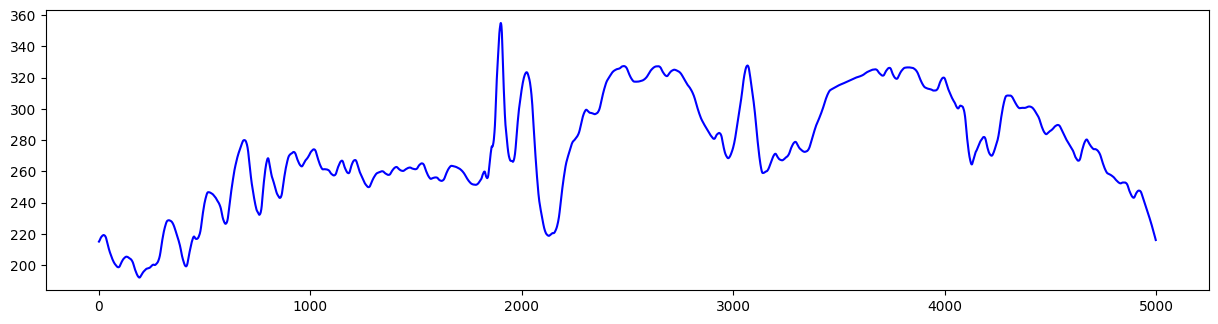

In [11]:
import matplotlib.pyplot as plt

x_batch, _ = train_seq[0]
reconstructed = model_v3_sf.predict(x_batch)

# İlk örneği seçelim
# reconstructed[0, :, 0] -> Sinyal kanalı
# reconstructed[0, :, 1] -> Peak kanalı

plt.figure(figsize=(15, 8))
plt.subplot(2,1,1)
plt.plot(x_batch[0, :, 0], label="Gerçek Sinyal (Yüksek Genlik)", color='blue')
plt.plot(reconstructed[0, :, 0], label="Model Çıktısı (Sıkışmış -1, 1)", color='red', alpha=0.8)
plt.title("Sinyal Karşılaştırma (Normalizasyonsuz)")
plt.legend()

plt.subplot(2,1,2)
plt.plot(x_batch[0, :, 1], label="Gerçek Peakler", color='green')
plt.plot(reconstructed[0, :, 1], label="Model Peak Tahmini", color='magenta', alpha=0.6)
plt.title("Peak Maskesi Karşılaştırma")
plt.legend()
plt.tight_layout()
plt.show()

1/1 [==============================] - 0s 16ms/step
Gerçek Sinyal Max: 355.0406188964844
Model Çıkışı Max: 1.0


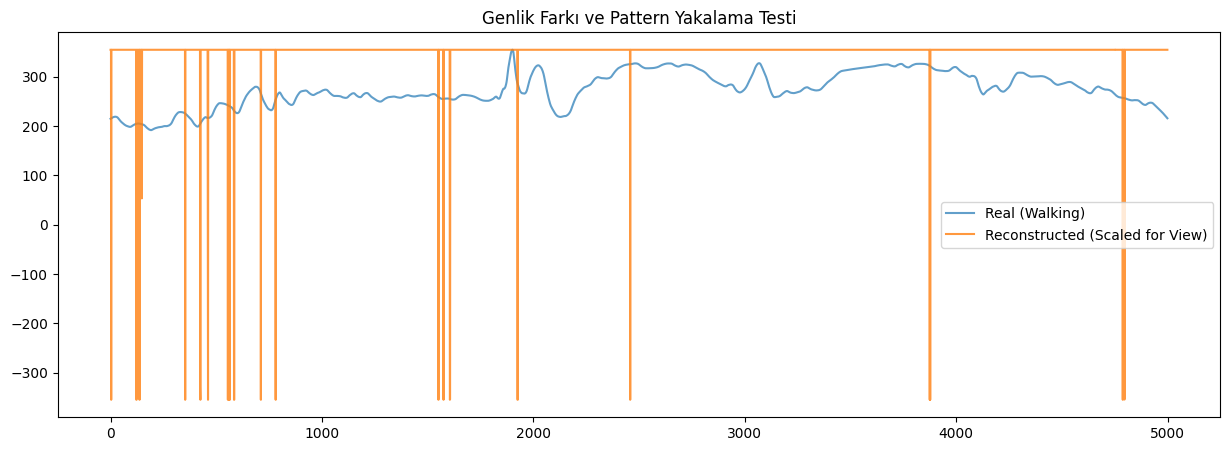

In [15]:
import numpy as np

# Eğitim bitince bir batch çek
x_batch, _ = train_seq[0]
# Mevcut (normalize edilmemiş) modelle tahmin yap
reconstructed_sig, reconstructed_peak = model_v3_sf.predict(x_batch)

print(f"Gerçek Sinyal Max: {np.max(x_batch[0,:,0])}")
print(f"Model Çıkışı Max: {np.max(reconstructed_sig[0,:,0])}")

plt.figure(figsize=(15, 5))
plt.plot(x_batch[0, :, 0], label="Real (Walking)", alpha=0.7)
plt.plot(reconstructed_sig[0, :, 0] * np.max(x_batch[0,:,0]), label="Reconstructed (Scaled for View)", alpha=0.8)
plt.title("Genlik Farkı ve Pattern Yakalama Testi")
plt.legend()
plt.show()

In [7]:
model_v2 = build_timesnet_unsupervised_v2()

In [8]:
model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss={
        "signal_output": "mse",                # Ham sinyal için
        "peak_output": "binary_crossentropy"   # Maske için
    },
    loss_weights={
        "signal_output": 1.0,
        "peak_output": 10.0  # Peak tespiti daha zordur, baskın hale getiriyoruz
    }
)

In [ ]:
hist_v2 = {"total":[], "sig":[], "peak":[]}

for epoch in range(50):
    for step in range(len(train_seq)):
        # Veriyi çek
        x_batch_raw, _ = train_seq[step]
        
        # 1. Normalizasyon uygula
        x_norm = normalize_walking_data(x_batch_raw)
        
        # 2. Hedefleri (Targets) ayır
        # Unsupervised olduğu için girişin aynısını hedefliyoruz
        y_signal = x_norm[:, :, 0:1] # Kanal 0
        y_peak = x_norm[:, :, 1:2]   # Kanal 1
        
        # 3. Eğitim adımı
        losses = model_v2.train_on_batch(
            x_norm, 
            {"signal_output": y_signal, "peak_output": y_peak}
        )
        
        # losses[0]: total_loss, losses[1]: sig_loss, losses[2]: peak_loss
        hist_v2["total"].append(losses[0])
        hist_v2["sig"].append(losses[1])
        hist_v2["peak"].append(losses[2])

    print(f"Epoch {epoch} | Total Loss: {losses[0]:.4f} | Sig MSE: {losses[1]:.4f} | Peak BCE: {losses[2]:.4f}")

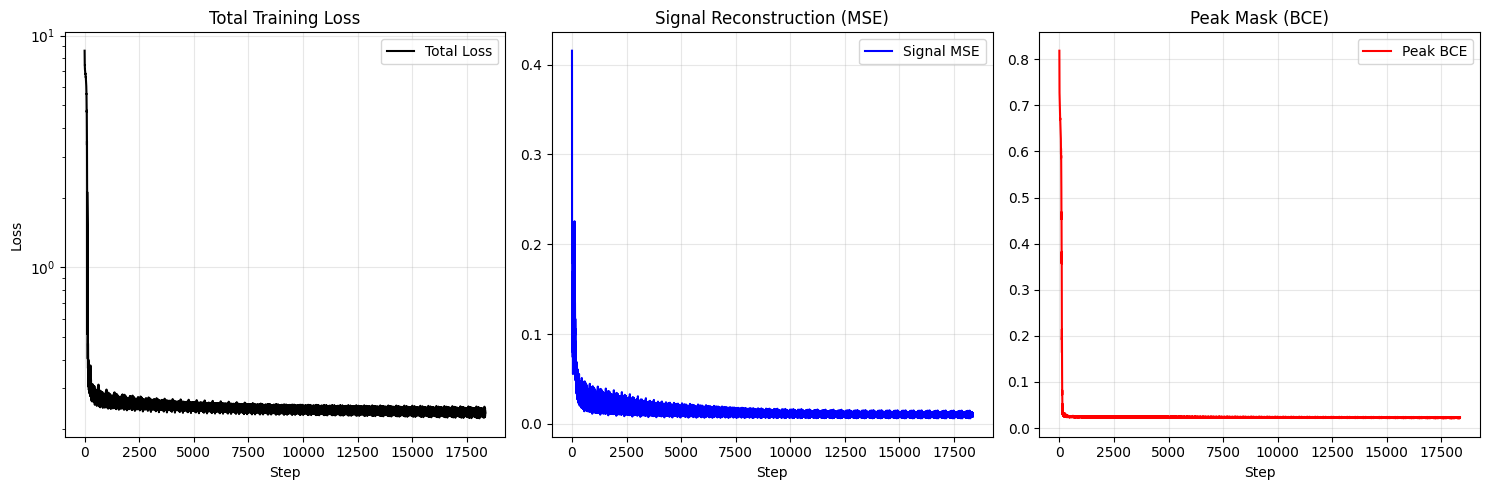

In [11]:
import matplotlib.pyplot as plt

def plot_training_history_v2(hist):
    epochs = range(len(hist["total"]))
    
    plt.figure(figsize=(15, 5))
    
    # 1. Toplam Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, hist["total"], label='Total Loss', color='black')
    plt.title('Total Training Loss')
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.yscale('log') # Kayıplar genelde logaritmik düşer
    plt.grid(True, alpha=0.3)
    plt.legend()

    # 2. Signal MSE (Sinyal kalitesi)
    plt.subplot(1, 3, 2)
    plt.plot(epochs, hist["sig"], label='Signal MSE', color='blue')
    plt.title('Signal Reconstruction (MSE)')
    plt.xlabel('Step')
    plt.grid(True, alpha=0.3)
    plt.legend()

    # 3. Peak BCE (Adım tespiti kalitesi)
    plt.subplot(1, 3, 3)
    plt.plot(epochs, hist["peak"], label='Peak BCE', color='red')
    plt.title('Peak Mask (BCE)')
    plt.xlabel('Step')
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

# Kullanımı:
plot_training_history_v2(hist_v2)

1/1 [==============================] - 0s 16ms/step


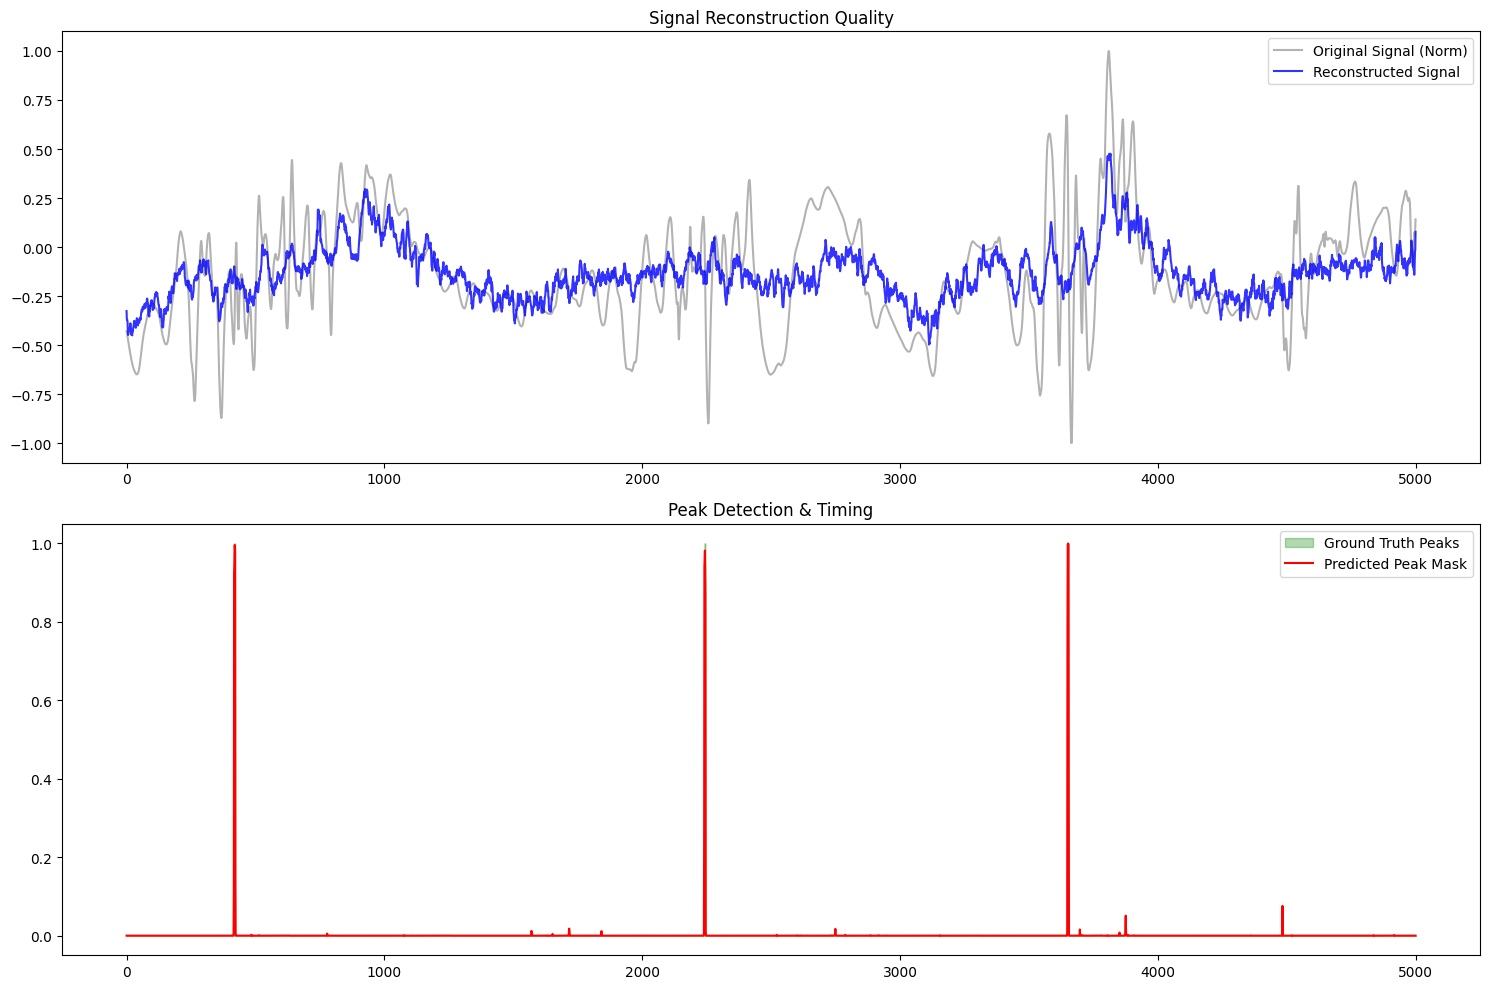

In [24]:
from sequences_peaks import normalize_walking_data
import matplotlib.pyplot as plt
def visualize_reconstruction(model, sequence, index=0):
    # Veriyi çek ve normalize et
    x_raw, _ = sequence[index]
    x_norm = normalize_walking_data(x_raw) # Daha önce yazdığımız fonksiyon
    
    # Modelden tahmin al
    # model_v2 iki çıktı veriyor: [signal, peak]
    pred_sig, pred_peak = model.predict(x_norm)
    
    # Görselleştirme
    sample_idx = 30 # Batch içindeki ilk örnek
    plt.figure(figsize=(15, 10))
    
    # Sinyal Kanalı
    plt.subplot(2, 1, 1)
    plt.plot(x_norm[sample_idx, :, 0], label='Original Signal (Norm)', alpha=0.6, color='gray')
    plt.plot(pred_sig[sample_idx, :, 0], label='Reconstructed Signal', alpha=0.8, color='blue')
    plt.title('Signal Reconstruction Quality')
    plt.legend()
    
    # Peak Kanalı
    plt.subplot(2, 1, 2)
    plt.fill_between(range(5000), x_norm[sample_idx, :, 1], color='green', alpha=0.3, label='Ground Truth Peaks')
    plt.plot(pred_peak[sample_idx, :, 0], color='red', label='Predicted Peak Mask')
    plt.title('Peak Detection & Timing')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Kullanımı:
visualize_reconstruction(model_v3_sf, train_seq, index=5)

In [13]:
model_v2.summary()

Model: "TimesNet_V2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 walking_input (InputLayer)  [(None, 20000, 2)]           0         []                            
                                                                                                  
 conv1d_3 (Conv1D)           (None, 20000, 64)            1472      ['walking_input[0][0]']       
                                                                                                  
 times_block_4 (TimesBlock)  (None, 20000, 64)            74112     ['conv1d_3[0][0]']            
                                                                                                  
 times_block_5 (TimesBlock)  (None, 20000, 64)            74112     ['times_block_4[0][0]']       
                                                                                        

In [2]:
model_v3 = TimesBlock.build_v3_pro()
import tensorflow as tf
model_v3.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss={"signal_output": "mse", "peak_output": "binary_crossentropy"},
    loss_weights={"signal_output": 1.0, "peak_output": 15.0} # Peaklere daha çok odaklan
)

2026-03-10 14:09:52.169385: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-10 14:09:52.179589: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-10 14:09:52.181508: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [3]:
import tensorflow as tf

def signal_quality_loss(y_true, y_pred):
    # 1. Standart MSE (Genel form)
    mse_loss = tf.reduce_mean(tf.square(y_true - y_pred))
    
    # 2. Gradient (Türev) Loss: Sinyalin değişim hızını yakalar (Adım vuruşları için)
    # [Batch, Time, 1] -> Fark alırken zamansal eksende fark alıyoruz
    true_diff = y_true[:, 1:, :] - y_true[:, :-1, :]
    pred_diff = y_pred[:, 1:, :] - y_pred[:, :-1, :]
    grad_loss = tf.reduce_mean(tf.abs(true_diff - pred_diff))
    
    # İkisini birleştir (0.5 ağırlık gradyan için idealdir)
    return mse_loss + 0.5 * grad_loss

In [4]:
# Modeli compile et

model_v3_sf = TimesBlock.build_v3_sf(window=5000)
model_v3_sf.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    # Her bir çıktı için farklı kayıp fonksiyonları
    loss={
        "signal_output": signal_quality_loss,  # Yukarıda tanımladığımız özel loss
        "peak_output": "binary_crossentropy"    # Adım var/yok kararı
    },
    
    # Kayıpların ağırlıklandırılması
    # Sinyal kalitesini artırmak için ağırlığını yükselttik
    loss_weights={
        "signal_output": 2.0,   # Sinyal dokusuna daha fazla önem ver
        "peak_output": 5.0      # Peakler zaten öğrenildiği için 15'ten 5'e çektik
    }
)

print("Model sinyal odaklı eğitim için hazır!")
model_v3_sf.summary()

Model sinyal odaklı eğitim için hazır!
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 walking_input (InputLayer)  [(None, 5000, 2)]            0         []                            
                                                                                                  
 conv1d_3 (Conv1D)           (None, 625, 64)              5312      ['walking_input[0][0]']       
                                                                                                  
 batch_normalization_4 (Bat  (None, 625, 64)              256       ['conv1d_3[0][0]']            
 chNormalization)                                                                                 
                                                                                                  
 leaky_re_lu (LeakyReLU)     (None, 625, 64)           

In [5]:
import os
import numpy as np
from sequences_peaks import normalize_batch
os.makedirs("models_v3_sf2", exist_ok=True)
best_loss = np.inf

for epoch in range(100):
    epoch_total_loss = []
    
    for step in range(len(train_seq)):
        x_raw, _ = train_seq[step]
        
        # 1. Ön İşleme (Wavelet Sequence içinde değilse burada yapıyoruz)
        # x_raw[:,:,0] = np.array([_wavelet_filter(s) for s in x_raw[:,:,0]])
        
        # 2. Normalizasyon
        x_norm = normalize_batch(x_raw.copy())
        
        # 3. Eğitim
        y_sig = x_norm[:, :, 0:1]
        y_peak = x_norm[:, :, 1:2]
        
        loss = model_v3_sf.train_on_batch(x_norm, {"signal_output": y_sig, "peak_output": y_peak})
        epoch_total_loss.append(loss[0])
    
    avg_loss = np.mean(epoch_total_loss)
    print(f"Epoch {epoch+1}/50 - Loss: {avg_loss:.6f}")
    
    # En iyi modeli kaydet
    if avg_loss < best_loss:
        best_loss = avg_loss
        model_v3_sf.save("models_v3_sf2/best_model_v3.keras")
        print("--> Best model updated!")
        
    # Her 5 epochta bir yedek al
    if (epoch + 1) % 10 == 0:
        model_v3_sf.save(f"models_v3_sf2/model_epoch_{epoch+1}.keras")

print("Eğitim başarıyla tamamlandı!")

2026-03-18 13:57:56.439871: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2026-03-18 13:58:06.692494: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f1d17a9f4b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-18 13:58:06.692517: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-03-18 13:58:06.701976: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773842286.774474  480722 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch 1/50 - Loss: 0.765703


2026-03-18 14:01:04.435366: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 163840000 exceeds 10% of free system memory.
2026-03-18 14:01:04.681398: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 163840000 exceeds 10% of free system memory.
2026-03-18 14:01:05.062809: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 163840000 exceeds 10% of free system memory.


--> Best model updated!
Epoch 2/50 - Loss: 0.357063


2026-03-18 14:03:27.079775: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 163840000 exceeds 10% of free system memory.
2026-03-18 14:03:27.330471: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 163840000 exceeds 10% of free system memory.


--> Best model updated!
Epoch 3/50 - Loss: 0.325605
--> Best model updated!
Epoch 4/50 - Loss: 0.309509
--> Best model updated!
Epoch 5/50 - Loss: 0.298412
--> Best model updated!
Epoch 6/50 - Loss: 0.290370
--> Best model updated!
Epoch 7/50 - Loss: 0.282866
--> Best model updated!
Epoch 8/50 - Loss: 0.276386
--> Best model updated!
Epoch 9/50 - Loss: 0.269550
--> Best model updated!
Epoch 10/50 - Loss: 0.263628
--> Best model updated!
Epoch 11/50 - Loss: 0.256310
--> Best model updated!
Epoch 12/50 - Loss: 0.250926
--> Best model updated!
Epoch 13/50 - Loss: 0.245296
--> Best model updated!
Epoch 14/50 - Loss: 0.240398
--> Best model updated!
Epoch 15/50 - Loss: 0.237548
--> Best model updated!
Epoch 16/50 - Loss: 0.233639
--> Best model updated!
Epoch 17/50 - Loss: 0.229614
--> Best model updated!
Epoch 18/50 - Loss: 0.226912
--> Best model updated!
Epoch 19/50 - Loss: 0.223777
--> Best model updated!
Epoch 20/50 - Loss: 0.220619
--> Best model updated!
Epoch 21/50 - Loss: 0.219622


In [10]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 4090, compute capability 8.9


2026-03-05 09:57:01.048295: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


In [ ]:
import os
import numpy as np
os.makedirs("models_v3_signalfocus", exist_ok=True)
best_loss = np.inf
from sequences_peaks import normalize_batch

for epoch in range(50):
    epoch_total_loss = []
    
    for step in range(len(train_seq)):
        x_raw, _ = train_seq[step]
        
        # 1. Ön İşleme (Wavelet Sequence içinde değilse burada yapıyoruz)
        # x_raw[:,:,0] = np.array([_wavelet_filter(s) for s in x_raw[:,:,0]])
        
        # 2. Normalizasyon
        x_norm = normalize_batch(x_raw.copy())
        
        # 3. Eğitim
        y_sig = x_norm[:, :, 0:1]
        y_peak = x_norm[:, :, 1:2]
        
        loss = model_v3_sf.train_on_batch(x_norm, {"signal_output": y_sig, "peak_output": y_peak})
        epoch_total_loss.append(loss[0])
    
    avg_loss = np.mean(epoch_total_loss)
    print(f"Epoch {epoch+1}/50 - Loss: {avg_loss:.6f}")
    
    # En iyi modeli kaydet
    if avg_loss < best_loss:
        best_loss = avg_loss
        model_v3_sf.save("models_v3_signalfocus/best_model_v3.keras")
        print("--> Best model updated!")
        
    # Her 5 epochta bir yedek al
    if (epoch + 1) % 5 == 0:
        model_v3_sf.save(f"models_v3_signalfocus/model_epoch_{epoch+1}.keras")

print("Eğitim başarıyla tamamlandı!")

In [8]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# 1. Custom fonksiyonları ve katmanları bir sözlükte topla
# Not: TimesBlock sınıfının kodunun yukarıdaki hücrelerde tanımlı olması gerekir.
custom_objects_dict = {
    'TimesBlock': TimesBlock,
    'signal_quality_loss': signal_quality_loss 
}
model_path = "/tf/start_training/TIMESNET_AUG/models_v3/best_model_v3.keras"
model_v3_sf = load_model(model_path, custom_objects=custom_objects_dict)
# Modeli ayıklayalım
# latent katmanının GİRİŞİNDEN itibaren başla, modelin ÇIKIŞINA kadar git
generator = tf.keras.Model(
    inputs=model_v3_sf.get_layer("latent").input, 
    outputs=model_v3_sf.output
)

print("Jeneratör başarıyla ayrıldı. Giriş boyutu: (None, 64)")
# Not: Önemli! latent katmanı aslında global_max_pooling'den gelen 64 kanalı bekliyor.

Jeneratör başarıyla ayrıldı. Giriş boyutu: (None, 64)


2026-03-13 10:59:13.439678: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906


1/1 [==============================] - 2s 2s/step


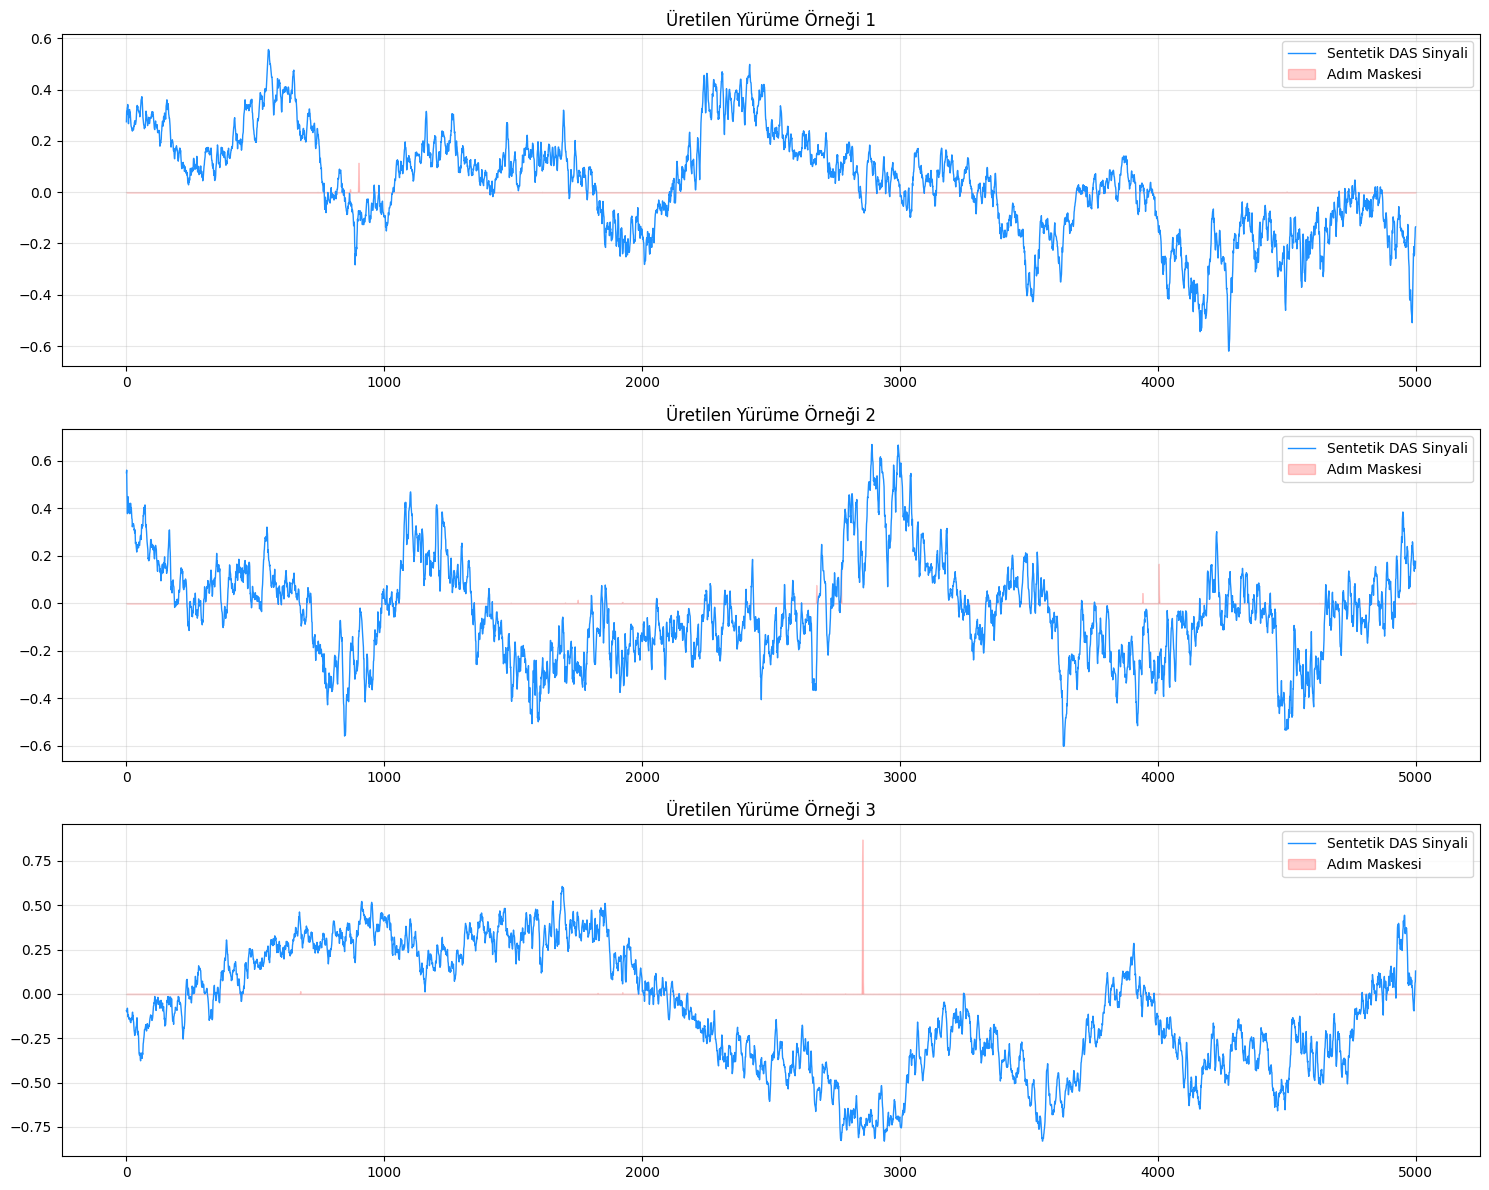

In [9]:
def generate_walking_signals(gen_model, n_samples=3):
    # 1. Latent space için rastgele vektör (64 boyutlu, summary'deki girişe uygun)
    random_latent = np.random.normal(size=(n_samples, 64))
    
    # 2. Üretim yap
    # gen_model bize [signal_output, peak_output] listesini döndürür
    predictions = gen_model.predict(random_latent)
    gen_sigs = predictions[0]
    gen_peaks = predictions[1]
    
    # 3. Görselleştirme
    plt.figure(figsize=(15, 4 * n_samples))
    for i in range(n_samples):
        plt.subplot(n_samples, 1, i+1)
        
        # Sinyal kanalı (Mavi)
        plt.plot(gen_sigs[i, :, 0], color='dodgerblue', label='Sentetik DAS Sinyali', linewidth=1)
        
        # Peak kanalı (Kırmızı alan)
        plt.fill_between(range(5000), gen_peaks[i, :, 0], color='red', alpha=0.2, label='Adım Maskesi')
        
        plt.title(f"Üretilen Yürüme Örneği {i+1}")
        plt.legend(loc='upper right')
        plt.grid(True, alpha=0.3)
        
    plt.tight_layout()
    plt.show()

# Çalıştır!
generate_walking_signals(generator, n_samples=3)

1/1 [==============================] - 0s 80ms/step


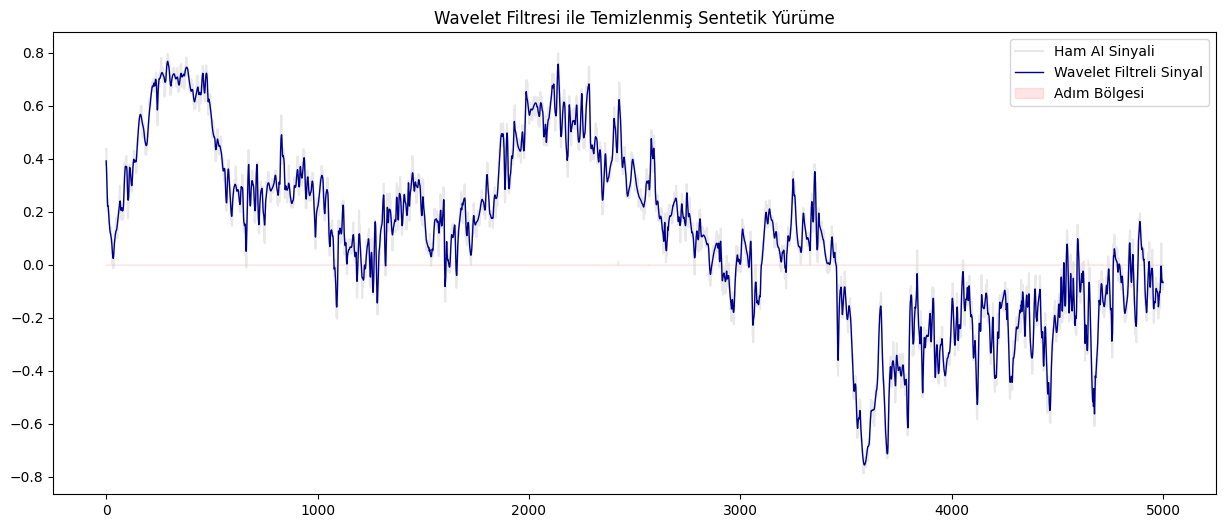

In [10]:
import pywt

def _wavelet_filter(data):
    wavelet = 'sym5'  # Yürüme sinyallerine en yakın formlardan biri
    maxlev = 5
    # Sinyali bileşenlerine ayır
    coeffs = pywt.wavedec(data, wavelet, level=maxlev, mode='symmetric')
    # Gürültü eşiğini (threshold) hesapla
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    uthresh = sigma * np.sqrt(2 * np.log(len(data)))
    # Detay katsayılarını (gürültüyü) temizle
    new_coeffs = [coeffs[0]]
    for i in range(1, maxlev + 1):
        new_coeffs.append(pywt.threshold(coeffs[i], uthresh, mode='soft'))
    # Sinyali geri inşa et
    return pywt.waverec(new_coeffs, wavelet, mode='symmetric')

def generate_and_filter_walking(gen_model, n_samples=3):
    # 1. Ham Sinyalleri Üret
    random_latent = np.random.normal(size=(n_samples, 64))
    predictions = gen_model.predict(random_latent)
    raw_sigs = predictions[0]  # (n, 5000, 1)
    gen_peaks = predictions[1] # (n, 5000, 1)
    
    filtered_sigs = []
    
    # 2. Wavelet Filtresini Uygula
    for i in range(n_samples):
        # Kanal 0'daki sinyali al, düzleştir ve filtrele
        s = raw_sigs[i, :, 0]
        f_s = _wavelet_filter(s)
        
        # Wavelet bazen uzunluğu 1-2 örnek değiştirebilir, orijinal boyuta sabitle
        if len(f_s) > 5000:
            f_s = f_s[:5000]
        elif len(f_s) < 5000:
            f_s = np.pad(f_s, (0, 5000 - len(f_s)), 'edge')
            
        filtered_sigs.append(f_s)
    
    filtered_sigs = np.array(filtered_sigs)
    
    # 3. Görselleştirme (Filtreli vs Ham)
    plt.figure(figsize=(15, 6))
    plt.plot(raw_sigs[0, :, 0], color='lightgray', alpha=0.5, label='Ham AI Sinyali')
    plt.plot(filtered_sigs[0], color='darkblue', linewidth=1, label='Wavelet Filtreli Sinyal')
    plt.fill_between(range(5000), gen_peaks[0, :, 0] * np.max(filtered_sigs[0]), 
                     color='red', alpha=0.1, label='Adım Bölgesi')
    plt.title("Wavelet Filtresi ile Temizlenmiş Sentetik Yürüme")
    plt.legend()
    plt.show()

    return filtered_sigs, gen_peaks

# Çalıştıralım
final_sigs, final_peaks = generate_and_filter_walking(generator)